In [1]:
from paths import *
from nano_maker.nanomaker import NanoMaker
from nano_maker.container.configs import skeleton_config, naanobot_config, radial_config

In [2]:
skeleton_weight_filename = "skeleton_e3.pt"
skeleton_cfg = skeleton_config
# naanobot_weight_filename = "naano_e3.pt"
# naanobot_config = naanobot_config
radial_cfg = radial_config

In [3]:
model = NanoMaker(skeleton_weight_filename=skeleton_weight_filename,
                  skeleton_cfg=skeleton_config,
                  radial_cfg=radial_cfg)

In [4]:
drug_i_want_to_deliver = "CC1=C(C=C(C=C1)NC(=O)C2=CC=C(C=C2)CN3CCN(CC3)C)NC4=NC=CC(=N4)C5=CN=CC=C5"

In [5]:
model.ingest_chemical(drug_i_want_to_deliver)

In [6]:
nano_product = model.generate()
nano_product

[[0.8947503272769083, 16.048908216219115, 0.5727065822052606],
 [7.721949898366145, 12.405666551951166, 2.643145078328696],
 [13.948815341700636, 2.137517176504235, 2.8922044112100185],
 [8.669432631541904, 10.794912047947463, 0.46562688427523097],
 [12.445019020671193, 3.919877206518834, 3.2734679024225386],
 [12.084450634642746, 0.6775700508491573, 5.074953546180287],
 [10.671282403648226, 3.4461851757994424, 5.972679371101496],
 [8.727594432589317, 8.540640707730631, 1.7767156673064153],
 [11.654202125837946, 1.2333038471865838, 3.178624882421597],
 [10.918669759562153, -0.9904589356721845, 4.441390138860701],
 [10.38697390680936, 2.740227428688678, 4.383579776042613],
 [9.576873700089546, 3.8541336569714977, 4.6626362076194665],
 [8.720958712245046, 6.620525842681021, 2.209074681217412],
 [6.170195023076819, 7.575146444662939, 4.938483628121548],
 [7.660465196947569, 7.228988411193913, 2.132110021465344],
 [1.0800757231496847, 7.507369842260539, 6.991230501858522],
 [5.744831947763

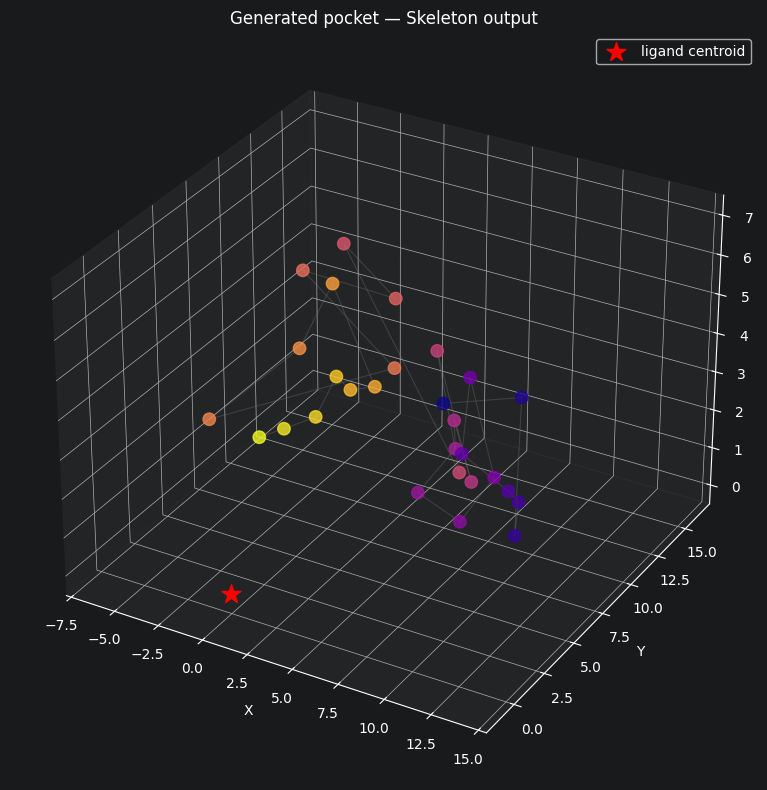

Radii (should be roughly decreasing):
  residue 1: 16.084
  residue 2: 14.850
  residue 3: 14.405
  residue 4: 13.853
  residue 5: 13.452
  residue 6: 13.124
  residue 7: 12.705
  residue 8: 12.340
  residue 9: 12.143
  residue 10: 11.829
  residue 11: 11.602
  residue 12: 11.327
  residue 13: 11.170
  residue 14: 10.947
  residue 15: 10.746
  residue 16: 10.315
  residue 17: 10.206
  residue 18: 10.013
  residue 19: 9.934
  residue 20: 9.472
  residue 21: 9.305
  residue 22: 9.037
  residue 23: 8.551
  residue 24: 8.211
  residue 25: 7.995
  residue 26: 7.650
  residue 27: 7.182
  residue 28: 6.187


In [7]:
# vibe coded visualizer -> will make my own

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

coords = np.array(nano_product)


fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# plot points colored by sequence order — early=dark, late=bright
ax.scatter(coords[:,0], coords[:,1], coords[:,2],
           c=np.linspace(0, 1, len(coords)),  # just pass the scalar values
           cmap='plasma', s=80, alpha=0.8)

# draw lines between consecutive points to see the sequence
for i in range(len(coords)-1):
    ax.plot([coords[i,0], coords[i+1,0]],
            [coords[i,1], coords[i+1,1]],
            [coords[i,2], coords[i+1,2]],
            'gray', alpha=0.3, linewidth=0.8)

# mark the origin (ligand centroid)
ax.scatter([0], [0], [0], c='red', s=200, marker='*', label='ligand centroid')

ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.set_title('Generated pocket — Skeleton output')
ax.legend()
plt.tight_layout()
plt.show()

# also print radii to verify ordering
radii = np.linalg.norm(coords, axis=1)
print("Radii (should be roughly decreasing):")
for i, r in enumerate(radii):
    print(f"  residue {i+1}: {r:.3f}")